In [1]:
import pandas as pd

# 파일 경로
file_path = '../data/chuncheon_data.csv'

# CSV 파일 로드
data = pd.read_csv(file_path)

# 데이터의 처음 몇 줄을 출력하여 확인
data.head()


,구분,유형,시도,시군,시설명,시설용량,도로명주소,위도,경도,소권역,연간처리량
0,하수처리시설,NaN,강원도,춘천시,춘천,150000.0,강원도 춘천시 영서로 2473,37.880234,127.710857,NaN,NaN
1,하수처리시설,NaN,강원도,춘천시,신북,4500.0,강원도 춘천시 신북읍 율문리 935-122,37.923463,127.742307,NaN,NaN
2,하수처리시설,NaN,강원도,춘천시,강촌,4000.0,강원도 춘천시 남산면 방곡리 산64,37.807063,127.643994,NaN,NaN
3,하수처리시설,NaN,강원도,춘천시,서면,1900.0,강원도 춘천시 서면 금산리 1120-24,37.899351,127.696634,NaN,NaN
4,하수처리시설,NaN,강원도,춘천시,지촌 신포리,490.0,강원도 춘천시 사북면 신포리 164-5,38.023148,127.645140,NaN,NaN


In [11]:
import osmnx as ox
import pandas as pd

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 결과 출력
print(data[['위도', '경도', 'nearest_node']])

# 결과를 새 CSV 파일로 저장
data.to_csv('../data/node_chuncheon_data.csv', index=False, encoding = 'utf-8')

           위도          경도  nearest_node
0   37.880234  127.710857    8711444376
1   37.923463  127.742307    5580438643
2   37.807063  127.643994    2783310550
3   37.899351  127.696634    5074269182
4   38.023148  127.645140     414666677
5   37.797360  127.773409     436695640
6   37.968125  127.666043     437101393
7   37.947266  127.730153     436960810
8   37.973112  127.597392   10293008343
9   37.738526  127.597057    2790752236
10  37.734761  127.575271    2790752236
11  37.737952  127.794449   11219440471
12  37.840791  127.552716    8891851350
13  37.959415  127.683688   10261892867
14  37.767363  127.802972   11219440471
15  37.858387  127.616831    2793995412
16  37.992202  127.702480   11171058924
17  37.880234  127.710857    8711444376
18  37.880234  127.710857    8711444376


In [12]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 첫 4개의 데이터에 대해 각각 다른 데이터와의 최단 거리 계산
first_four = data.head(4)
facility_names = first_four['시설명']
nodes = first_four['nearest_node']
distances = pd.DataFrame(index=facility_names, columns=facility_names)

for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if node1 != node2:
            # 노드간 최단 거리 계산
            length = nx.shortest_path_length(G, node1, node2, weight='length')
            distances.iloc[i, j] = length

# 결과 출력
distances


시설명,춘천,신북,강촌,서면
시설명,,,,
춘천,NaN,6179.934,14639.037,9813.993
신북,6587.277,NaN,20739.944,6323.294
강촌,14661.42,20677.181,NaN,14834.811
서면,9766.633,6542.821,14818.532,NaN


~\anaconda3\envs\base1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
~\anaconda3\envs\base1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
~\anaconda3\envs\base1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
~\anaconda3\envs\base1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
~\anaconda3\envs\base1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44620 (\N{HANGUL SYLLABLE GGA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
~\anaconda3\envs\base1\lib\site-pac

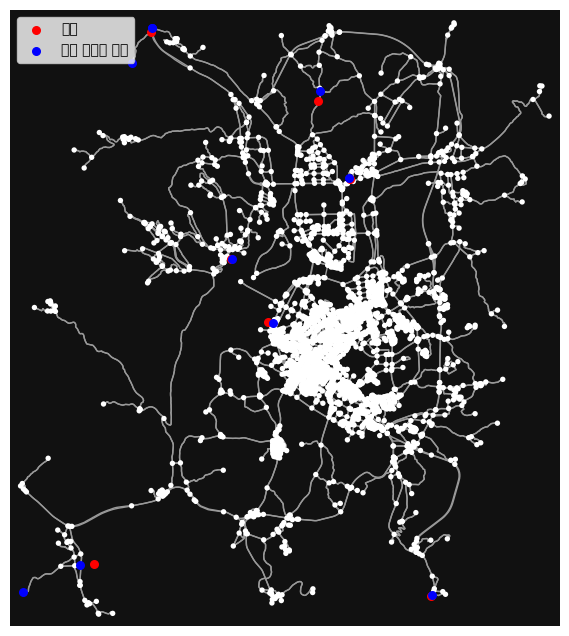

In [16]:
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 맵 생성
fig, ax = ox.plot_graph(G, show=False, close=False)

# 처음 10개의 데이터에 대해 각각 다른 데이터와의 최단 거리 계산
first_ten = data.head(10)

# 점의 크기 설정 (예: 50)
marker_size = 30

# 각 시설의 위치를 맵에 표시
for idx, row in first_ten.iterrows():
    ax.scatter(row['경도'], row['위도'], c='red', s=marker_size, label='시설' if idx == 0 else "")
    nearest_node = G.nodes[row['nearest_node']]
    ax.scatter(nearest_node['x'], nearest_node['y'], c='blue', s=marker_size, label='가장 가까운 노드' if idx == 0 else "")

# 범례 추가
ax.legend()

# 표시
plt.show()


In [17]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 시설명과 노드 ID를 연결
facility_names = data['시설명']
nodes = data['nearest_node']

# 최단 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)

# 모든 시설 노드 쌍에 대한 최단 거리 계산
for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if node1 != node2:
            try:
                length = nx.shortest_path_length(G, node1, node2, weight='length')
                distances.iloc[i, j] = length
            except nx.NetworkXNoPath:
                distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# 결과 출력
distances


시설명,춘천,신북,강촌,서면,지촌 신포리,원창리,오월,지내리,지암,바깥,가정리,조양리,다릿골,용산리,상명암,안반지,고탄마을,하수슬러지 자원화시설,춘천시청
시설명,,,,,,,,,,,,,,,,,,,
춘천,NaN,6179.934,14639.037,9813.993,13282.849,11994.306,13308.17,8913.467,14754.369,16456.117,16456.117,12450.141,15079.653,11560.444,12450.141,16395.369,11378.91,NaN,NaN
신북,6587.277,NaN,20739.944,6323.294,9282.74,16764.203,9308.061,3969.816,10754.26,22557.024,22557.024,17220.038,21180.56,7560.335,17220.038,22496.276,6435.259,6587.277,6587.277
강촌,14661.42,20677.181,NaN,14834.811,24799.102,19813.717,24824.423,22228.262,26270.622,2410.252,2410.252,20269.552,3748.316,24875.239,20269.552,5064.032,24693.705,14661.42,14661.42
서면,9766.633,6542.821,14818.532,NaN,10366.173,20606.248,10391.494,7795.333,11837.693,16635.612,16635.612,21062.083,15259.148,10442.31,21062.083,16574.864,10260.776,9766.633,9766.633
지촌 신포리,13269.128,9700.065,24840.895,10424.245,NaN,24108.743,25.321,8559.496,1471.52,26657.975,26657.975,24564.578,25281.511,1722.405,24564.578,26597.227,7571.841,13269.128,13269.128
원창리,11997.077,16497.358,19886.706,20665.394,24134.25,NaN,24159.571,19764.868,25605.77,21703.786,21703.786,455.835,20327.322,22411.845,455.835,21643.038,22230.311,11997.077,11997.077
오월,13474.461,10250.649,24815.574,10398.924,3927.471,24314.076,NaN,11503.161,1446.199,26632.654,26632.654,24769.911,25256.19,5649.876,24769.911,26571.906,11499.312,13474.461,13474.461
지내리,8916.037,4263.769,22261.913,7845.263,8559.496,19755.652,8584.817,NaN,10031.016,24078.993,24078.993,20211.487,22702.529,6837.091,20211.487,24018.245,2465.443,8916.037,8916.037
지암,14920.66,11696.848,26261.773,11845.123,5373.67,25760.275,1446.199,12949.36,NaN,28078.853,28078.853,26216.11,26702.389,7096.075,26216.11,28018.105,12945.511,14920.66,14920.66


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


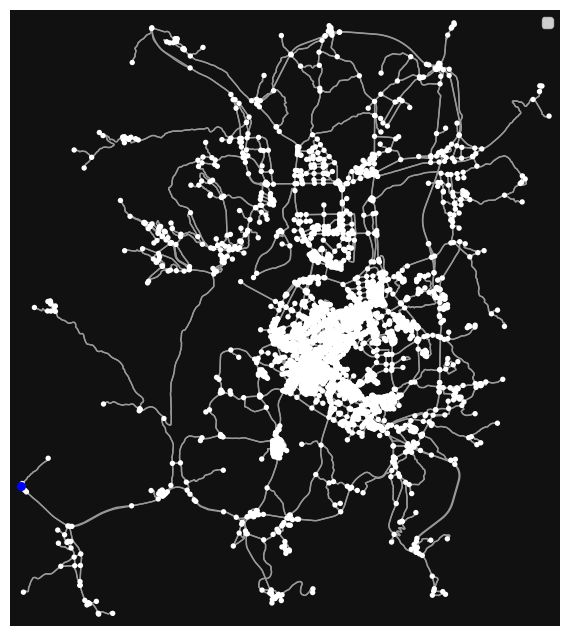

In [23]:
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 맵 생성
fig, ax = ox.plot_graph(G, show=False, close=False)

# 처음 10개의 데이터에 대해 각각 다른 데이터와의 최단 거리 계산
selected_data = data.iloc[12:13]

# 점의 크기 설정 (예: 50)
marker_size = 30

# 각 시설의 위치를 맵에 표시
for idx, row in selected_data.iterrows():
    ax.scatter(row['경도'], row['위도'], c='red', s=marker_size, label='facility' if idx == 0 else "")
    nearest_node = G.nodes[row['nearest_node']]
    ax.scatter(nearest_node['x'], nearest_node['y'], c='blue', s=marker_size, label='nearest_node' if idx == 0 else "")

# 범례 추가
ax.legend()

# 표시
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


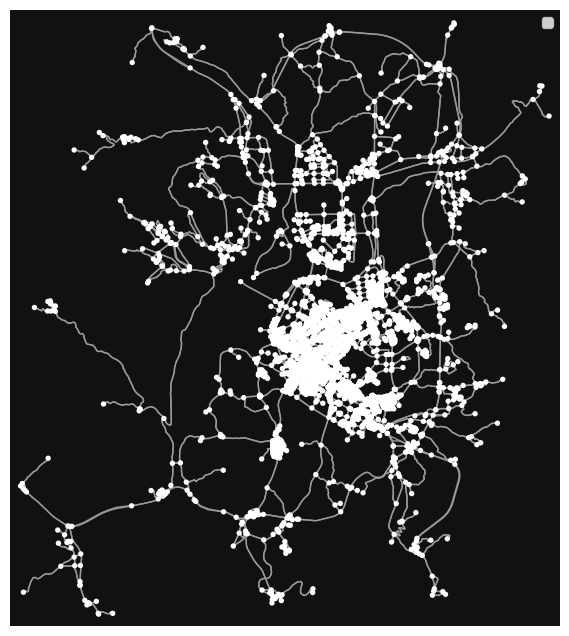

In [24]:
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 맵 생성
fig, ax = ox.plot_graph(G, show=False, close=False)

# 처음 10개의 데이터에 대해 각각 다른 데이터와의 최단 거리 계산
selected_data = data.iloc[12:13]

# 점의 크기 설정 (예: 50)
marker_size = 30

# 각 시설의 위치를 맵에 표시
for idx, row in selected_data.iterrows():
    ax.scatter(row['경도'], row['위도'], c='red', s=marker_size, label='facility' if idx == 0 else "")

# 범례 추가
ax.legend()

# 표시
plt.show()


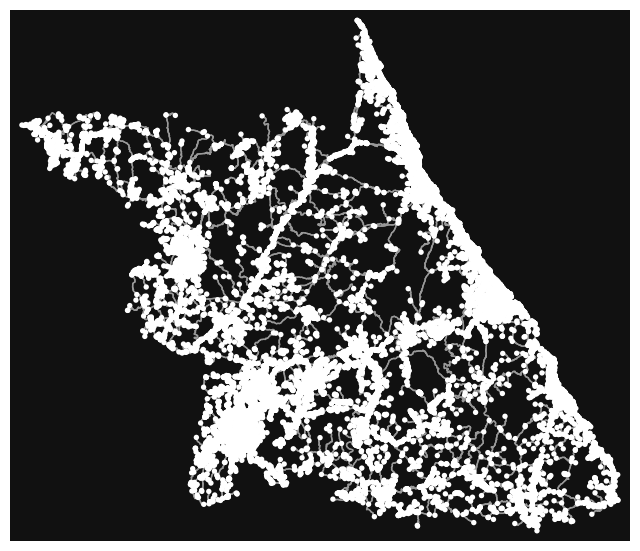

AttributeError: module 'osmnx' has no attribute 'get_nearest_node'

In [25]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 강원도 춘천의 중심 좌표를 기준으로 도로 네트워크를 로드
center_point = (37.8813, 127.7298)  # 춘천시 중심 좌표
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')
fig, ax = ox.plot_graph(G)


# 시설 데이터 불러오기
facilities = pd.read_csv('../data/filtered.csv')

# 각 시설의 좌표에 대해 가장 가까운 도로 노드 찾기
nearest_nodes = []
for idx, row in facilities.iterrows():
    point = (row['위도'], row['경도'])
    nearest_node = ox.get_nearest_node(G, point)
    nearest_nodes.append(nearest_node)

# 가장 가까운 노드 정보 추가
facilities['nearest_node'] = nearest_nodes

# 결과를 CSV로 저장
facilities.to_csv('../data/facilities_with_nearest_nodes.csv', index=False)


In [26]:
import osmnx as ox
import pandas as pd

# 데이터 로드
data = pd.read_csv('../data/filtered.csv')


G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 결과 출력
print(data[['위도', '경도', 'nearest_node']])

# 결과를 새 CSV 파일로 저장
data.to_csv('../data/node_gangwon.csv', index=False, encoding = 'utf-8')

           위도          경도  nearest_node
0   37.880234  127.710857    8711444376
1   37.923463  127.742307    5580438643
2   37.807063  127.643994    2783310550
3   37.899351  127.696634    5074269182
4   37.390776  127.938717   11836533339
..        ...         ...           ...
78  37.386789  127.939983    5578719984
79  38.130821  127.289909    4663118855
80  37.707132  127.837152   11013649370
81  37.707132  127.837152   11013649370
82  37.491190  127.908843    1445324755

[83 rows x 3 columns]


In [27]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 데이터 로드
data = pd.read_csv('../data/filtered.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 시설명과 노드 ID를 연결
facility_names = data['시설명']
nodes = data['nearest_node']

# 최단 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)

# 모든 시설 노드 쌍에 대한 최단 거리 계산
for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if node1 != node2:
            try:
                length = nx.shortest_path_length(G, node1, node2, weight='length')
                distances.iloc[i, j] = length
            except nx.NetworkXNoPath:
                distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# 결과 출력
distances


시설명,춘천,신북,강촌,서면,원주,원주기업도시,문막,흥업,강릉,북강릉,...,음식물처리시설,횡성군 음식물 처리시설,환경자원사업소,음식물처리시설,음식물처리시설,원주,철원,홍천1,홍천2,횡성
시설명,,,,,,,,,,,,,,,,,,,,,
춘천,NaN,6179.934,14639.037,9813.993,73024.357,78696.005,90405.701,80772.906,158908.582,143169.294,...,109382.537,60669.246,89875.315,68699.031,121889.767,72771.936,79682.521,29345.693,29345.693,66133.89
신북,6587.277,NaN,20739.944,6323.294,77794.254,83465.902,95175.598,85542.803,157211.408,141472.12,...,103393.674,65439.143,85875.206,62710.168,115900.904,77541.833,75682.412,34115.59,34115.59,70903.787
강촌,14661.42,20677.181,NaN,14834.811,75416.522,82486.788,94196.484,83820.614,160796.656,145057.368,...,123508.259,62475.803,101391.568,82824.753,136015.489,75819.644,91198.774,30270.574,30270.574,67688.565
서면,9766.633,6542.821,14818.532,NaN,81636.299,87307.947,99017.643,89384.848,162893.064,147153.776,...,109075.33,69081.283,86958.639,68391.824,121582.56,81383.878,76765.845,37505.848,37505.848,74294.045
원주,72135.521,76612.943,75749.491,80803.838,NaN,10768.497,22368.214,10343.063,115754.737,116967.665,...,138247.78,16161.56,160865.16,104033.903,156913.5,2388.341,150672.366,45478.917,45478.917,26331.327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
원주,72531.982,77009.404,76145.952,81200.299,2391.184,10086.343,21123.627,9098.476,115922.994,117135.922,...,138644.241,16558.021,161261.621,104430.364,157309.961,NaN,151068.827,45875.378,45875.378,25649.173
철원,79661.32,76092.257,91233.087,76816.437,151530.986,157202.634,168912.33,159279.535,223710.264,207970.976,...,169892.53,139175.875,22404.726,129209.024,182399.76,151278.565,NaN,107852.322,107852.322,144640.519
홍천1,29417.869,33918.15,30270.574,37910.476,45145.948,52628.908,64696.17,53550.04,138067.423,123192.774,...,106523.859,32205.229,118147.508,66439.527,119319.124,45549.07,107954.714,NaN,NaN,37417.991


In [29]:
# distances 데이터 프레임을 CSV 파일로 저장
distances.to_csv('../data/distances1.csv', encoding='CP949')


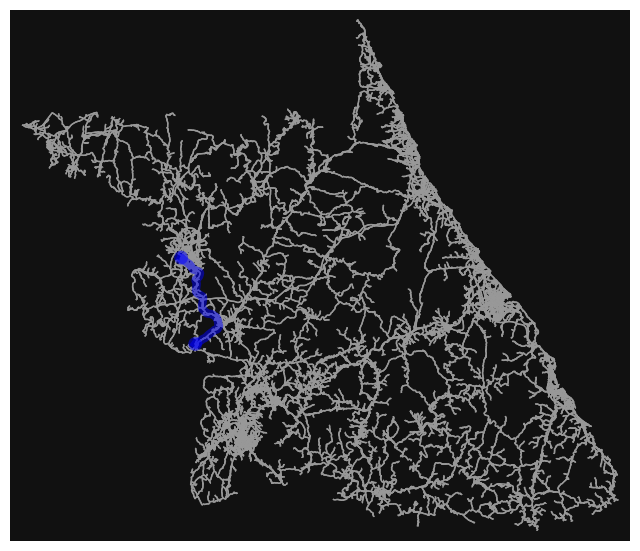

In [41]:
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('../data/node_gangwon.csv')

# 강원특별자치도의 도로 네트워크 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 시각화할 두 노드 선택 (예제로 첫 두 노드를 사용)
node1 = data['nearest_node'].iloc[0]
node2 = data['nearest_node'].iloc[21]

# 최단 경로 찾기
route = nx.shortest_path(G, node1, node2, weight='length')

# 경로 시각화
fig, ax = ox.plot_graph_route(G, route, route_color='blue', route_linewidth=6, node_size=0)

# 표시
plt.show()


In [35]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 데이터 로드
data = pd.read_csv('../data/node_gangwon.csv')

# 시설명과 노드 ID를 연결
facility_names = data['시설명']
nodes = data['nearest_node']

# 최단 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)

# 모든 시설 노드 쌍에 대한 최단 거리 계산
for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if node1 != node2:
            try:
                length = nx.shortest_path_length(G, node1, node2, weight='length')
                distances.iloc[i, j] = length
            except nx.NetworkXNoPath:
                distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# CSV 파일로 저장
distances.to_csv('../data/distances.csv', encoding='CP949')


# 결과 출력
distances

In [38]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 강원특별자치도의 도로 네트워크 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# node_gangwon.csv에서 노드 데이터 로드
node_data = pd.read_csv('../data/node_gangwon.csv')
facility_names = node_data['시설명']
nodes = node_data['nearest_node']
categories = node_data['구분']

# 최단 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)
for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        # 다른 '구분'을 가진 노드 쌍에 대해서만 계산
        if node1 != node2 and categories[i] != categories[j]:
            try:
                length = nx.shortest_path_length(G, node1, node2, weight='length')
                distances.iloc[i, j] = length
            except nx.NetworkXNoPath:
                distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# 결과 저장
distances.to_csv('../data/filtered_distances.csv', encoding='CP949')
print(distances)

시설명         춘천         신북         강촌         서면          원주      원주기업도시  \
시설명                                                                       
춘천         NaN        NaN        NaN        NaN         NaN         NaN   
신북         NaN        NaN        NaN        NaN         NaN         NaN   
강촌         NaN        NaN        NaN        NaN         NaN         NaN   
서면         NaN        NaN        NaN        NaN         NaN         NaN   
원주         NaN        NaN        NaN        NaN         NaN         NaN   
..         ...        ...        ...        ...         ...         ...   
원주   72531.982  77009.404  76145.952  81200.299    2391.184   10086.343   
철원    79661.32  76092.257  91233.087  76816.437  151530.986  157202.634   
홍천1  29417.869   33918.15  30270.574  37910.476   45145.948   52628.908   
홍천2  29417.869   33918.15  30270.574  37910.476   45145.948   52628.908   
횡성    66176.64  70676.921  67789.522  74669.247   26303.458   22508.207   

시설명         문막          

In [39]:
distances.to_csv('../data/filtered_distances.csv', encoding='CP949')


In [42]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 강원특별자치도의 도로 네트워크 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# node_gangwon.csv에서 노드 데이터 로드
node_data = pd.read_csv('../data/node_gangwon.csv')
facility_names = node_data['시설명']
nodes = node_data['nearest_node']
categories = node_data['구분']

# 왕복 평균 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)
for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if node1 != node2 and categories[i] != categories[j]:
            try:
                length1 = nx.shortest_path_length(G, node1, node2, weight='length')
                length2 = nx.shortest_path_length(G, node2, node1, weight='length')
                avg_length = (length1 + length2) / 2
                distances.iloc[i, j] = avg_length
            except nx.NetworkXNoPath:
                distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# 결과 저장
distances.to_csv('../data/avg_round_trip_distances.csv', encoding='CP949')
print(distances)

시설명          춘천          신북          강촌          서면          원주      원주기업도시  \
시설명                                                                           
춘천          NaN         NaN         NaN         NaN         NaN         NaN   
신북          NaN         NaN         NaN         NaN         NaN         NaN   
강촌          NaN         NaN         NaN         NaN         NaN         NaN   
서면          NaN         NaN         NaN         NaN         NaN         NaN   
원주          NaN         NaN         NaN         NaN         NaN         NaN   
..          ...         ...         ...         ...         ...         ...   
원주    72651.959  77275.6185   75982.798  81292.0885   2389.7625  10080.2725   
철원   79671.9205  75887.3345  91215.9305   76791.141  151101.676  157144.009   
홍천1   29381.781    34016.87   30270.574   37708.162  45312.4325  52638.3855   
홍천2   29381.781    34016.87   30270.574   37708.162  45312.4325  52638.3855   
횡성    66155.265   70790.354  67739.0435   74481.646 

In [47]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 강원특별자치도의 도로 네트워크 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# node_gangwon.csv에서 노드 데이터 로드
node_data = pd.read_csv('../data/node_gangwon_시설이름.csv')
facility_names = node_data['시설이름']
nodes = node_data['nearest_node']
categories = node_data['구분']

# bio.csv에서 특정 지점 좌표 로드
bio_data = pd.read_csv('../data/bio.csv')
center_point = (bio_data['위도'][0], bio_data['경도'][0])  # 첫 번째 데이터 사용
center_node = ox.nearest_nodes(G, center_point[1], center_point[0])

# 최단 거리 계산 및 왕복 평균 거리 계산
distances = pd.DataFrame(index=facility_names, columns=facility_names)
to_remove = []

# 5km 이내 노드 체크
for idx, node in enumerate(nodes):
    try:
        if nx.shortest_path_length(G, center_node, node, weight='length') <= 5000:
            to_remove.append(idx)  # 5km 이내 노드 인덱스 저장
    except nx.NetworkXNoPath:
        continue

# 왕복 평균 거리 계산 (제거 대상이 아닌 노드들만)
for i, node1 in enumerate(nodes):
    if i in to_remove:
        continue
    for j, node2 in enumerate(nodes):
        if j in to_remove or i == j or categories[i] != categories[j]:
            continue
        try:
            length1 = nx.shortest_path_length(G, node1, node2, weight='length')
            length2 = nx.shortest_path_length(G, node2, node1, weight='length')
            avg_length = (length1 + length2) / 2
            distances.iloc[i, j] = avg_length
        except nx.NetworkXNoPath:
            distances.iloc[i, j] = None  # 경로가 없는 경우 None으로 설정

# 결과 저장
distances.to_csv('../data/avg_round_trip_distances_filtered.csv', encoding='CP949')
print(distances)

시설이름           하수처리시설 춘천   하수처리시설 신북   하수처리시설 강촌   하수처리시설 서면   하수처리시설 원주  \
시설이름                                                                       
하수처리시설 춘천            NaN   6383.6055  14650.2285    9790.313   72579.939   
하수처리시설 신북      6383.6055         NaN  20708.5625   6433.0575  77203.5985   
하수처리시설 강촌     14650.2285  20708.5625         NaN  14826.6715  75583.0065   
하수처리시설 서면       9790.313   6433.0575  14826.6715         NaN  81220.0685   
하수처리시설 원주      72579.939  77203.5985  75583.0065  81220.0685         NaN   
...                  ...         ...         ...         ...         ...   
가축분뇨처리시설 원주          NaN         NaN         NaN         NaN         NaN   
가축분뇨처리시설 철원          NaN         NaN         NaN         NaN         NaN   
가축분뇨처리시설 홍천1         NaN         NaN         NaN         NaN         NaN   
가축분뇨처리시설 홍천2         NaN         NaN         NaN         NaN         NaN   
가축분뇨처리시설 횡성          NaN         NaN         NaN         NaN         NaN   

시설이름       

In [48]:
import osmnx as ox
import pandas as pd
import networkx as nx

# 강원특별자치도의 도로 네트워크 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')

# node_gangwon.csv에서 노드 데이터 로드
node_data = pd.read_csv('../data/node_gangwon_시설이름.csv')
facility_names = node_data['시설이름']
nodes = node_data['nearest_node']
categories = node_data['구분']

# bio.csv에서 특정 지점 좌표 로드
bio_data = pd.read_csv('../data/bio.csv')
center_point = (bio_data['위도'][0], bio_data['경도'][0])
center_node = ox.nearest_nodes(G, center_point[1], center_point[0])

# 5km 이내 노드 체크 및 제외
to_remove = []
for idx, node in enumerate(nodes):
    try:
        if nx.shortest_path_length(G, center_node, node, weight='length') <= 5000:
            to_remove.append(idx)
    except nx.NetworkXNoPath:
        continue

# 최단 거리 계산 및 왕복 평균 거리 계산 (제거 대상이 아닌 노드들만, 다른 '구분'끼리)
distances = pd.DataFrame(index=facility_names, columns=facility_names)
for i, node1 in enumerate(nodes):
    if i in to_remove:
        continue
    for j, node2 in enumerate(nodes):
        if j in to_remove or i == j or categories[i] == categories[j]:
            continue
        try:
            length1 = nx.shortest_path_length(G, node1, node2, weight='length')
            length2 = nx.shortest_path_length(G, node2, node1, weight='length')
            avg_length = (length1 + length2) / 2
            distances.iloc[i, j] = avg_length
        except nx.NetworkXNoPath:
            distances.iloc[i, j] = None

# 결과 저장
distances.to_csv('../data/avg_round_trip_distances_filtered.csv', encoding='CP949')
print(distances)

시설이름           하수처리시설 춘천   하수처리시설 신북   하수처리시설 강촌   하수처리시설 서면   하수처리시설 원주  \
시설이름                                                                       
하수처리시설 춘천            NaN         NaN         NaN         NaN         NaN   
하수처리시설 신북            NaN         NaN         NaN         NaN         NaN   
하수처리시설 강촌            NaN         NaN         NaN         NaN         NaN   
하수처리시설 서면            NaN         NaN         NaN         NaN         NaN   
하수처리시설 원주            NaN         NaN         NaN         NaN         NaN   
...                  ...         ...         ...         ...         ...   
가축분뇨처리시설 원주    72651.959  77275.6185   75982.798  81292.0885   2389.7625   
가축분뇨처리시설 철원   79671.9205  75887.3345  91215.9305   76791.141  151101.676   
가축분뇨처리시설 홍천1   29381.781    34016.87   30270.574   37708.162  45312.4325   
가축분뇨처리시설 홍천2   29381.781    34016.87   30270.574   37708.162  45312.4325   
가축분뇨처리시설 횡성    66155.265   70790.354  67739.0435   74481.646  26317.3925   

시설이름       

In [55]:
import pandas as pd

# node_gangwon_시설이름.csv 파일 로드
data = pd.read_csv("../data/node_gangwon_시설이름.csv")



# 5km 사각형 범위 내의 시설들을 각각 처리
filtered_facilities = []

for index, facility in data.iterrows():
    # 5km 사각형 내에 있는 시설들 중에서 같은 유형의 시설 찾기
    same_type_facilities = data[
        (data['위도'] >= facility['위도'] - 0.04521855) & (data['위도'] <= facility['위도'] + 0.04521855) &
        (data['경도'] >= facility['경도'] - 0.0556738) & (data['경도'] <= facility['경도'] + 0.0556738) &
        (data['유형'] == facility['유형'])  # 시설 유형이 같은 경우
    ]
    
    # 시설 용량이 가장 큰 시설 선택
    if not same_type_facilities.empty:
        largest_facility = same_type_facilities.loc[same_type_facilities['시설용량'].idxmax()]
        filtered_facilities.append(largest_facility)

# 선택된 시설들을 데이터프레임으로 변환
filtered_facilities_df = pd.DataFrame(filtered_facilities)

# 결과 저장
filtered_facilities_df.to_csv('../data/filtered_facilities_5km.csv', index=False)




# 겹치는 시설들을 그룹화하기 위해 고유한 그룹 ID를 할당
overlapping_facilities_df['그룹ID'] = overlapping_facilities_df.groupby(['시설명']).ngroup()

# 지도 초기 설정
m = folium.Map(location=[37.5, 128], zoom_start=9)

# 마커 클러스터 생성
marker_cluster = MarkerCluster().add_to(m)

# 각 그룹에 대해 고유한 색상 할당
group_colors = {}
for group_id in overlapping_facilities_df['그룹ID'].unique():
    group_colors[group_id] = f'#{random.randint(0, 0xFFFFFF):06x}'  # 랜덤 색상 생성

# 겹치는 시설들을 지도에 추가
for idx, facility in overlapping_facilities_df.iterrows():
    folium.Marker(
        location=[facility['위도'], facility['경도']],
        popup=facility['시설명'],  # 팝업에 시설명 추가
        clustered_marker=True,  # 클러스터링된 마커 사용
        icon=None,  # 기본 아이콘 사용
        icon_color=group_colors[facility['그룹ID']],  # 그룹별 색상 지정
    ).add_to(marker_cluster)

# 지도를 HTML 파일로 저장하여 확인
m


KeyError: nan

In [57]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# 파일 불러오기
file_path = '../data/node_gangwon_합본.csv'
data = pd.read_csv(file_path)

# 데이터 확인
data.head(), data.columns

# 바이오가스화시설 데이터 필터링
biogas_data = data[data['구분'] == '바이오가스화시설']

# 히트맵 데이터 생성
# 바이오가스화시설에 음의 가중치 적용
heatmap_data = []
for _, row in data.iterrows():
    if row['구분'] == '바이오가스화시설':
        weight = -10  # 바이오가스화시설에는 음의 효과
    else:
        weight = 1   # 기타 시설에는 양의 효과
    heatmap_data.append([row['위도'], row['경도'], weight])

# 지도 중심을 강원도 지역으로 설정
map_center = [37.75, 128.0]  # 강원도의 대략적인 중심 좌표
map = folium.Map(location=map_center, zoom_start=9)

# 히트맵 추가
HeatMap(heatmap_data).add_to(map)

# 맵 파일 저장
map_path = '../data/gangwon_facilities_heatmap1.html'
map.save(map_path)

map_path


'gangwon_facilities_heatmap1.html'

In [58]:
from geopy.distance import geodesic

# 5km 범위 내의 시설 제외하고 히트맵 데이터 준비
def is_within_5km(point1, point2):
    """두 좌표 사이의 거리가 5km 이내인지 확인."""
    distance = geodesic(point1, point2).km
    return distance < 5

# 바이오가스화시설의 좌표 목록
biogas_coordinates = biogas_data[['위도', '경도']].values.tolist()

# 모든 시설 중 바이오가스화시설 5km 이내에 없는 시설만 히트맵 데이터로 사용
new_heatmap_data = []
for _, row in data.iterrows():
    facility_coord = (row['위도'], row['경도'])
    # 바이오가스화시설 중 어느 하나라도 5km 이내에 있는지 검사
    if not any(is_within_5km(facility_coord, biogas_coord) for biogas_coord in biogas_coordinates):
        # 바이오가스화시설과 5km 이내에 없는 시설만 히트맵 데이터에 추가
        new_heatmap_data.append([row['위도'], row['경도'], 1])  # 모든 시설 양의 가중치

# 새로운 히트맵 생성
new_map = folium.Map(location=map_center, zoom_start=9)
HeatMap(new_heatmap_data).add_to(new_map)

# 새 맵 파일 저장
new_map_path = '../data/gangwon_facilities_heatmap_excluded.html'
new_map.save(new_map_path)

new_map_path


'gangwon_facilities_heatmap_excluded.html'

In [65]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from geopy.distance import geodesic

# 데이터 로딩
file_path = '../data/node_gangwon_합본.csv'  # 수정 필요: 실제 파일 경로로 대체
data = pd.read_csv(file_path)

# 거리 계산 도우미 함수
def is_within_5km(point1, point2):
    return geodesic(point1, point2).km < 5

# 시설 유형별 색상 지정 함수
def get_color(facility_type):
    return {
        '바이오가스화시설': 'green',
        '하수처리시설': 'blue',
        '음식물류폐기물처리시설': 'orange',
        '가축분뇨처리시설': 'red',
        '하수찌꺼기처리시설': 'purple'
    }.get(facility_type, 'gray')  # 기본값은 회색

# 바이오가스화시설 데이터 및 필터링
biogas_data = data[data['구분'] == '바이오가스화시설']
data_non_biogas = data[data['구분'] != '바이오가스화시설']
data_non_biogas['weight'] = 1

# 바이오가스화시설 5km 이내 데이터 제외
biogas_coords = biogas_data[['위도', '경도']].values.tolist()
not_near_biogas = data.copy()
for index, row in data.iterrows():
    if any(is_within_5km((row['위도'], row['경도']), coord) for coord in biogas_coords):
        not_near_biogas = not_near_biogas.drop(index)

not_near_biogas['weight'] = 1

# 지도 및 히트맵 생성 및 저장 함수
def create_map(data, title):
    map_center = [data['위도'].mean(), data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    for _, row in data.iterrows():
        folium.Marker(
            location=(row['위도'], row['경도']),
            popup=f"{row['구분']}: {row['시설명']}",
            icon=folium.Icon(color=get_color(row['구분']))
        ).add_to(map_obj)
    map_obj.save(f'../data/{title}.html')

def create_heatmap(data, title):
    map_center = [data['위도'].mean(), data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    heatmap_data = data[['위도', '경도', 'weight']].values.tolist()
    HeatMap(heatmap_data).add_to(map_obj)
    map_obj.save(f'../data/{title}.html')

# 지도 및 데이터 저장
create_map(data_non_biogas, 'map_excluding_biogas')
create_map(not_near_biogas, 'map_excluding_nearby_biogas')
create_heatmap(data_non_biogas, 'heatmap_excluding_biogas')
create_heatmap(not_near_biogas, 'heatmap_excluding_nearby_biogas')

~\AppData\Local\Temp\ipykernel_25144\720330489.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_non_biogas['weight'] = 1


In [67]:
not_near_biogas.to_csv('../data/data_excluding_nearby_biogas.csv', index=False, encoding='CP949')

In [68]:
data = pd.read_csv('../data/바이오인접제외.csv', encoding='cp949')
data.head()

facility_count = data['시군'].value_counts().reset_index()
facility_count.columns = ['시군', '시설 수']
facility_count_sorted = facility_count.sort_values(by='시설 수', ascending=False)
facility_count_sorted

,시군,시설 수
0,인제군,7
1,양구군,7
2,평창군,6
3,삼척시,5
4,철원군,5
5,횡성군,5
10,강릉시,4
9,양양군,4
8,정선군,4
7,고성군,4


In [69]:
# 데이터 로딩
file_path = '../data/node_gangwon_합본.csv'  # 수정 필요: 실제 파일 경로로 대체
data = pd.read_csv(file_path)

# 거리 계산 도우미 함수
def is_within_5km(point1, point2):
    return geodesic(point1, point2).km < 5

# 시설 유형별 색상 지정 함수
def get_color(facility_type):
    return {
        '바이오가스화시설': 'green',
        '하수처리시설': 'blue',
        '음식물류폐기물처리시설': 'orange',
        '가축분뇨처리시설': 'red',
        '하수찌꺼기처리시설': 'purple'
    }.get(facility_type, 'gray')  # 기본값은 회색

# 바이오가스화시설 데이터 및 필터링
biogas_data = data[data['구분'] == '바이오가스화시설']
data_non_biogas = data[data['구분'] != '바이오가스화시설']
data_non_biogas['weight'] = 1

# 바이오가스화시설 5km 이내 데이터 제외
biogas_coords = biogas_data[['위도', '경도']].values.tolist()
not_near_biogas = data.copy()
for index, row in data.iterrows():
    if any(is_within_5km((row['위도'], row['경도']), coord) for coord in biogas_coords):
        not_near_biogas = not_near_biogas.drop(index)

not_near_biogas['weight'] = 1

# 지도 및 히트맵 생성 및 저장 함수
def create_map(data, title):
    map_center = [data['위도'].mean(), data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    for _, row in data.iterrows():
        folium.Marker(
            location=(row['위도'], row['경도']),
            popup=f"{row['구분']}: {row['시설명']}",
            icon=folium.Icon(color=get_color(row['구분']))
        ).add_to(map_obj)
    map_obj.save(f'../data/{title}.html')

def create_heatmap(data, title):
    map_center = [data['위도'].mean(), data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    heatmap_data = data[['위도', '경도', 'weight']].values.tolist()
    HeatMap(heatmap_data).add_to(map_obj)
    map_obj.save(f'../data/{title}.html')

# 지도 및 데이터 저장
create_map(data, 'map')

~\AppData\Local\Temp\ipykernel_25144\140674076.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_non_biogas['weight'] = 1
